In [1]:
import pandas as pd
import numpy as np
import joblib

from itertools import combinations

In [2]:
df = pd.read_csv("odi_final_dataset.csv")

xgb_model = joblib.load("xgb_model.pkl")

feature_columns = joblib.load(
    "feature_columns.pkl"
)

In [3]:
world_cup_teams = [
    "India",
    "Australia",
    "England",
    "Pakistan",
    "New Zealand",
    "South Africa",
    "Sri Lanka",
    "Bangladesh",
    "West Indies",
    "Afghanistan"
]

In [4]:
team_strength = {}

teams = pd.concat(
    [df["team1"], df["team2"]]
).unique()

for team in teams:

    matches = df[
        (df["team1"] == team) |
        (df["team2"] == team)
    ]

    wins = (
        matches["winner"] == team
    ).sum()

    team_strength[team] = (
        wins / len(matches)
    )

In [9]:
def get_recent_form(team):

    matches = df[
        (df["team1"] == team) |
        (df["team2"] == team)
    ].tail(10)

    wins = (
        matches["winner"] == team
    ).sum()

    return wins

In [10]:
def get_h2h(team1, team2):

    h2h_matches = df[
        (
            (df["team1"] == team1)
            &
            (df["team2"] == team2)
        )
        |
        (
            (df["team1"] == team2)
            &
            (df["team2"] == team1)
        )
    ]

    team1_wins = (
        h2h_matches["winner"] == team1
    ).sum()

    team2_wins = (
        h2h_matches["winner"] == team2
    ).sum()

    return team1_wins, team2_wins

In [11]:
def create_match_features(team1, team2):

    X_pred = pd.DataFrame(
        np.zeros((1, len(feature_columns))),
        columns=feature_columns
    )

    X_pred["team1_recent_form"] = (
        get_recent_form(team1)
    )

    X_pred["team2_recent_form"] = (
        get_recent_form(team2)
    )

    h2h1, h2h2 = get_h2h(
        team1,
        team2
    )

    X_pred["team1_h2h_wins"] = h2h1
    X_pred["team2_h2h_wins"] = h2h2

    X_pred["team1_strength"] = (
        team_strength.get(team1, 0.5)
    )

    X_pred["team2_strength"] = (
        team_strength.get(team2, 0.5)
    )

    X_pred["toss_match_win"] = (
        np.random.randint(0, 2)
    )

    team1_col = f"team1_{team1}"

    if team1_col in X_pred.columns:
        X_pred[team1_col] = 1

    team2_col = f"team2_{team2}"

    if team2_col in X_pred.columns:
        X_pred[team2_col] = 1

    return X_pred

In [12]:
test = create_match_features(
    "India",
    "Australia"
)

print(test.shape)

(1, 293)


In [20]:
def simulate_match_xgb(team1, team2):

    X_pred = create_match_features(
        team1,
        team2
    )

    probs = xgb_model.predict_proba(X_pred)[0]

    prob_team2 = float(probs[0])
    prob_team1 = float(probs[1])

    # Safety Check

    if np.isnan(prob_team1) or np.isnan(prob_team2):

        prob_team1 = 0.5
        prob_team2 = 0.5

    # Normalize Probabilities

    total = prob_team1 + prob_team2

    prob_team1 = prob_team1 / total
    prob_team2 = prob_team2 / total

    winner = np.random.choice(
        [team1, team2],
        p=[prob_team1, prob_team2]
    )

    return winner

In [21]:
for i in range(10):
    print(
        simulate_match_xgb(
            "India",
            "Australia"
        )
    )

India
Australia
Australia
Australia
India
Australia
India
India
Australia
Australia


In [15]:
print(test.shape)

(1, 293)


In [22]:
from itertools import combinations

matches = list(
    combinations(
        world_cup_teams,
        2
    )
)

print(len(matches))

45


In [23]:
def simulate_world_cup_playoffs():

    points = {
        team: 0
        for team in world_cup_teams
    }

    # League Stage
    for team1, team2 in matches:

        winner = simulate_match_xgb(
            team1,
            team2
        )

        points[winner] += 2

    standings = pd.DataFrame(
        points.items(),
        columns=["Team", "Points"]
    )

    standings = standings.sort_values(
        "Points",
        ascending=False
    ).reset_index(drop=True)

    top4 = standings.head(4)["Team"].tolist()

    # Semi Final 1
    sf1_winner = simulate_match_xgb(
        top4[0],
        top4[3]
    )

    # Semi Final 2
    sf2_winner = simulate_match_xgb(
        top4[1],
        top4[2]
    )

    # Final
    champion = simulate_match_xgb(
        sf1_winner,
        sf2_winner
    )

    return champion

In [24]:
simulate_world_cup_playoffs()

np.str_('South Africa')

In [25]:
winner_count = {
    team: 0
    for team in world_cup_teams
}

In [26]:
for i in range(1000):

    champion = simulate_world_cup_playoffs()

    winner_count[champion] += 1

In [27]:
wc_prob = pd.DataFrame(
    winner_count.items(),
    columns=["Team", "Titles"]
)

wc_prob["Win_Chance_%"] = (
    wc_prob["Titles"] / 1000
) * 100

wc_prob = wc_prob.sort_values(
    "Win_Chance_%",
    ascending=False
).reset_index(drop=True)

wc_prob["Rank"] = range(
    1,
    len(wc_prob) + 1
)

wc_prob = wc_prob[
    ["Rank", "Team", "Titles", "Win_Chance_%"]
]

wc_prob

,Rank,Team,Titles,Win_Chance_%
0,1,Australia,212,21.2
1,2,New Zealand,163,16.3
2,3,England,159,15.9
3,4,South Africa,146,14.6
4,5,India,141,14.1
5,6,Pakistan,114,11.4
6,7,Sri Lanka,28,2.8
7,8,Bangladesh,27,2.7
8,9,West Indies,10,1.0
9,10,Afghanistan,0,0.0


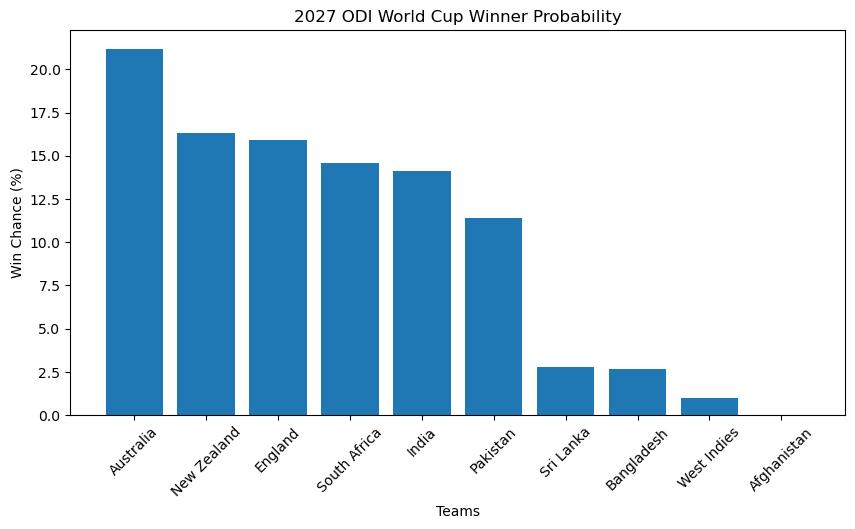

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    wc_prob["Team"],
    wc_prob["Win_Chance_%"]
)

plt.title(
    "2027 ODI World Cup Winner Probability"
)

plt.xlabel("Teams")
plt.ylabel("Win Chance (%)")

plt.xticks(rotation=45)

plt.show()